# Prediction Accuracy Overview

Shows when predictions are correct vs incorrect (no attributions).

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from tqdm.auto import tqdm

from src.interpretability.config.helpdesk_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation

%matplotlib inline

In [2]:
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
                         growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)

# Activity label mapping
concept_id = eval_helper.concept_name_id
inv_cats = eval_helper.inverted_suffix_categories[concept_id]

print(f"Cases: {len(eval_helper.cases)}, Suffix length: {model.seq_len_pred}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

In [3]:
# Collect predictions - use suffix tensor for ground truth (like ProcessPerformanceMap)
results = []

for case_name, case in tqdm(eval_helper.cases.items(), desc="Evaluating"):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(case):
        # Ground truth: first non-zero activity in suffix tensor
        suffix_cats = suffix[0]
        gt_idx = suffix_cats[concept_id][0, 0].item()
        if gt_idx == 0:  # Skip padding
            continue
        gt_activity = inv_cats.get(gt_idx, str(gt_idx))
        
        # Model prediction (first step only)
        with torch.no_grad():
            predictions, _, _, _ = model(prefix)
        
        cat_preds, num_preds = predictions
        activity_logits = cat_preds[f'{CONFIG.concept_name}_mean']
        if activity_logits.dim() == 3:
            activity_logits = activity_logits[0]  # First suffix step
        
        pred_idx = activity_logits.argmax(dim=-1).item()
        pred_activity = inv_cats.get(pred_idx, str(pred_idx))
        
        results.append({
            'prefix_len': prefix_len,
            'predicted': pred_activity,
            'ground_truth': gt_activity,
            'correct': pred_idx == gt_idx
        })

print(f"Total predictions: {len(results)}")
print(f"Overall accuracy: {sum(r['correct'] for r in results) / len(results):.1%}")

Evaluating:   0%|          | 0/916 [00:00<?, ?it/s]

Total predictions: 3329
Overall accuracy: 65.4%


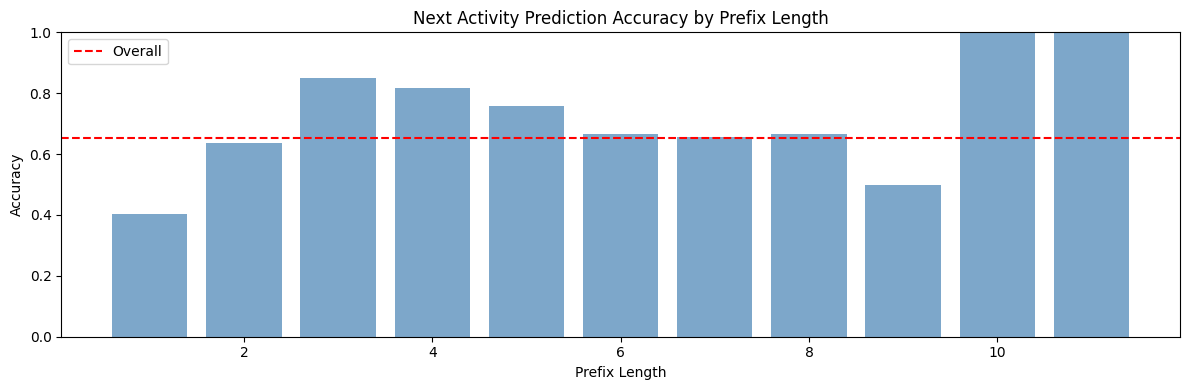


Accuracy by prefix length:
  Prefix 1: 40.4% (n=916)
  Prefix 2: 63.5% (n=916)
  Prefix 3: 84.9% (n=878)
  Prefix 4: 81.8% (n=357)
  Prefix 5: 75.7% (n=148)
  Prefix 6: 66.7% (n=66)
  Prefix 7: 65.5% (n=29)
  Prefix 8: 66.7% (n=12)
  Prefix 9: 50.0% (n=4)
  Prefix 10: 100.0% (n=2)
  Prefix 11: 100.0% (n=1)


In [4]:
# Accuracy by prefix length
prefix_lens = sorted(set(r['prefix_len'] for r in results))

accs, counts = [], []
for pl in prefix_lens:
    pl_results = [r for r in results if r['prefix_len'] == pl]
    accs.append(sum(r['correct'] for r in pl_results) / len(pl_results))
    counts.append(len(pl_results))

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(prefix_lens, accs, color='steelblue', alpha=0.7)
ax.set_xlabel('Prefix Length')
ax.set_ylabel('Accuracy')
ax.set_title('Next Activity Prediction Accuracy by Prefix Length')
ax.set_ylim(0, 1)
ax.axhline(y=sum(r['correct'] for r in results)/len(results), color='red', linestyle='--', label='Overall')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nAccuracy by prefix length:")
for pl, acc, cnt in zip(prefix_lens, accs, counts):
    print(f"  Prefix {pl}: {acc:.1%} (n={cnt})")

In [5]:
# Most common errors
errors = [(r['ground_truth'], r['predicted']) for r in results if not r['correct']]
error_counts = Counter(errors)

print(f"Total errors: {len(errors)} ({len(errors)/len(results):.1%})")
print("\nTop 10 error patterns (ground_truth -> predicted):")
for (gt, pred), cnt in error_counts.most_common(10):
    print(f"  {gt} -> {pred}: {cnt}")

Total errors: 1152 (34.6%)

Top 10 error patterns (ground_truth -> predicted):
  Take in charge ticket -> Resolve ticket: 537
  Wait -> Resolve ticket: 175
  Assign seriousness -> Take in charge ticket: 121
  Wait -> Take in charge ticket: 104
  Resolve ticket -> Take in charge ticket: 97
  Resolve ticket -> Closed: 41
  Take in charge ticket -> Closed: 14
  Require upgrade -> Take in charge ticket: 13
  Closed -> Resolve ticket: 12
  Require upgrade -> Resolve ticket: 6


In [6]:
# Per-activity accuracy
gt_to_preds = defaultdict(Counter)
for r in results:
    gt_to_preds[r['ground_truth']][r['predicted']] += 1

print("Per-activity accuracy:")
for gt in sorted(gt_to_preds.keys()):
    total = sum(gt_to_preds[gt].values())
    correct = gt_to_preds[gt].get(gt, 0)
    print(f"  {gt}: {correct}/{total} = {correct/total:.1%}")

Per-activity accuracy:
  Assign seriousness: 0/123 = 0.0%
  Closed: 900/916 = 98.3%
  Create SW anomaly: 0/12 = 0.0%
  INVALID: 0/1 = 0.0%
  RESOLVED: 0/1 = 0.0%
  Require upgrade: 0/21 = 0.0%
  Resolve SW anomaly: 0/2 = 0.0%
  Resolve ticket: 848/987 = 85.9%
  Schedule intervention: 0/1 = 0.0%
  Take in charge ticket: 429/981 = 43.7%
  VERIFIED: 0/1 = 0.0%
  Wait: 0/283 = 0.0%
